In [2]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

from ultralytics import YOLO

### Prepare the dataset by converting the CrowdHuman annotations to YOLO format and organizing the images and labels into the appropriate directories.

- This only needs to be done once, and the resulting dataset can be used for training the YOLO model.

In [3]:
# convert_crowd_human_to_yolo(
#     annotation_file="CrowdHuman/annotation_train.odgt",
#     image_dir="CrowdHuman/CrowdHuman_train",
#     out_image_dir="datasets/crowdhuman_vbox/images/train",
#     out_label_dir="datasets/crowdhuman_vbox/labels/train",
#     box_type="vbox",
# )

# convert_crowd_human_to_yolo(
#     annotation_file="CrowdHuman/annotation_val.odgt",
#     image_dir="CrowdHuman/CrowdHuman_val",
#     out_image_dir="datasets/crowdhuman_vbox/images/val",
#     out_label_dir="datasets/crowdhuman_vbox/labels/val",
#     box_type="vbox",
# )

Note: The same needs to be done with the WiderPerson, OCHuman and COCO-Person datasets if you want to use them for training as well.
- The conversion scripts are available in the `scripts/conversions` directory of the repository.

#### Test the conversion by visualizing the bounding boxes on some sample images

In [4]:
def draw_yolo_labels(image_path, label_path):
    img = cv2.imread(str(image_path))
    H, W = img.shape[:2]

    with open(label_path, "r", encoding="utf-8") as f:
        for line in f:
            cls, xc, yc, bw, bh = map(float, line.split())

            x1 = int((xc - bw / 2) * W)
            y1 = int((yc - bh / 2) * H)
            x2 = int((xc + bw / 2) * W)
            y2 = int((yc + bh / 2) * H)

            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")

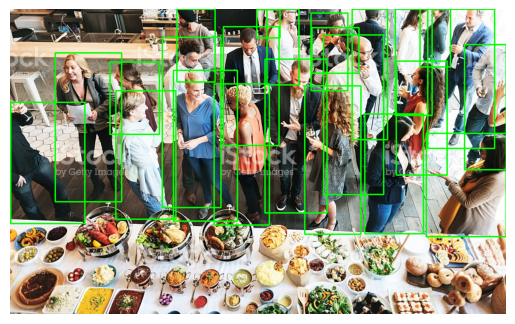

In [5]:
# CrowdHuman
draw_yolo_labels(
    image_path=Path("./datasets/crowdhuman_vbox/images/train/273271,1a0d6000b9e1f5b7.jpg"),
    label_path=Path("./datasets/crowdhuman_vbox/labels/train/273271,1a0d6000b9e1f5b7.txt"),
)

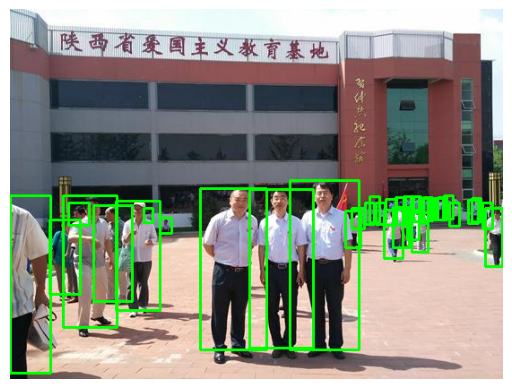

In [6]:
# WiderPerson
draw_yolo_labels(
    image_path=Path("./datasets/widerperson/images/train/000040.jpg"),
    label_path=Path("./datasets/widerperson/labels/train/000040.txt"),
)

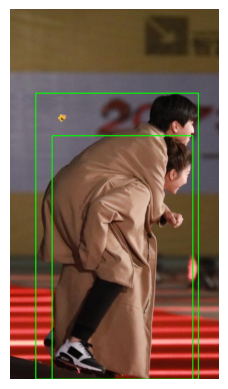

In [7]:
# CrowdHuman
draw_yolo_labels(
    image_path=Path("./datasets/ochuman/images/train/000012.jpg"),
    label_path=Path("./datasets/ochuman/labels/train/000012.txt"),
)

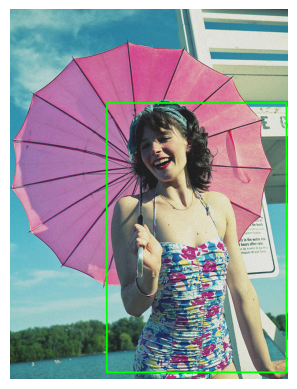

In [10]:
# COCO-Person
draw_yolo_labels(
    image_path=Path("./datasets/coco2017/images/train/000000000036.jpg"),
    label_path=Path("./datasets/coco2017/labels/train/000000000036.txt"),
)

## Model fine-tuning

In [8]:
model = YOLO("yolo26n.pt")

In [9]:
model.train(
    data="datasets/crowdhuman_vbox/data.yaml",
    epochs=50,
    imgsz=960,
    batch=8,
    device=0,
    patience=15,
    project="runs/person_detection",
    name="yolo26n_crowdhuman_vbox_960",
)

Ultralytics 8.4.48  Python-3.12.13 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2060, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets/crowdhuman_vbox/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26n_crowdhuman_vbox_960-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=

KeyboardInterrupt: 